# **Spotify-Music-Trend-Analysis - EDA**

## Objectives

- Provide insights on Dataset
- Provide Insights on ETL process, including
    - Reason for Column Removal
    - Reason for Column Addition 


## Inputs

CSV file cleaned in ETL:

spotifydataset_Cleaned.csv


Note: file stored in assets/csv/CleanedFiles


## Outputs

No Physical Output

Insights on the data.
Insights on the ETL process.


---

## Initalise Working Environment

In [1]:
#import libraries
import os
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

#below solution provided by chatGPT 
import sys
from pathlib import Path


current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
current_dir

'd:\\Coding Cooler Dump\\Spotify-Music-Trend-Analysis-1\\jupyter_notebooks'

---

# Loading Raw Data

---

In [2]:
# Loading the dataset as df
dfraw = pd.read_csv("assets/csv/OriginalFiles/spotifydataset.csv")

# Allowing all columns to be displayed at once.
pd.set_option('display.max_columns', None)
# Displaying the first 5 rows of the dataset, to confirm it has been loaded.
dfraw.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Raw Data Overview

In [3]:
dfraw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

- 114000 total rows
- 21 total columns
- no Null values in any column

---

# Loading Cleaned Data

In [9]:
# Loading the dataset as df
df = pd.read_csv("assets/csv/VisualisationFiles/spotify_dashboard_data.csv")

# Allowing all columns to be displayed at once.
pd.set_option('display.max_columns', None)
# Displaying the first 5 rows of the dataset, to confirm it has been loaded.
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance
1,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop
2,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton
3,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop
4,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,latino


# Cleaned Data Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89379 entries, 0 to 89378
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           89379 non-null  object 
 1   album_name        89379 non-null  object 
 2   track_name        89379 non-null  object 
 3   popularity        89379 non-null  int64  
 4   duration_ms       89379 non-null  int64  
 5   explicit          89379 non-null  bool   
 6   danceability      89379 non-null  float64
 7   energy            89379 non-null  float64
 8   key               89379 non-null  int64  
 9   loudness          89379 non-null  float64
 10  mode              89379 non-null  int64  
 11  speechiness       89379 non-null  float64
 12  acousticness      89379 non-null  float64
 13  instrumentalness  89379 non-null  float64
 14  liveness          89379 non-null  float64
 15  valence           89379 non-null  float64
 16  tempo             89379 non-null  float6

- 89379 total rows
- 19 total columns
- no Null values in any column

---

# Comparing Clean and Raw Data

As is clear in the loading of the data after going through the ETL process, there is a total of 19 columns, as opposed to the initial 21 in the raw dataset. 

This is due to the removal of 2 columns titled :


"Unnamed: 0"

"track_id"

Which both, to some extent, functioned as indexes. "track_id" also served an additional purpose, as an identifier for duplicate appearances of songs, but for the usage of a cleaned dataset, it holds no value.

In addition to the removal of 2 redundant columns, the dataset was also reduced from 114,000 total rows down to 89379, as the others were found to be duplicates, through using track_id, or otherwise removed - there was a single row that contained a erroneous data, cleaned in the ETL by removing.

---

# Basic Visualisations

Within the Dataset, there were a few areas of immediate interest, such as the impact of the inclusion of explicit language on popularity.
To this end, these basic visualisations have been included.

First, the disparity in songs that contain explicit lyrics to those that do not will be highlighted with a simple countplot

In [6]:
sns.countplot(data=df, x="explicit")
plt.bar_label(plt.gca().containers[0],
              label_type='center')
plt.title("Explicit to Non-Explicit", fontsize=15)
plt.xticks([0,1], ['Non-Explicit', 'Explicit'])
plt.xlabel("Is Explicit?")
plt.show()

<Figure size 640x480 with 1 Axes>

As visible, the disparity is gargantuan, with the count of non-explicit songs being 2 orders of magnitude greater to that of explicit songs. This is relevant to how the difference should be highlighted if compared in the future, as simply showing that more Non-explicit songs are in the top 10 songs or other such metrics will not be helpful, due to the size of each category.

Following this, A visualisation will be created to show the average popularity of either category.

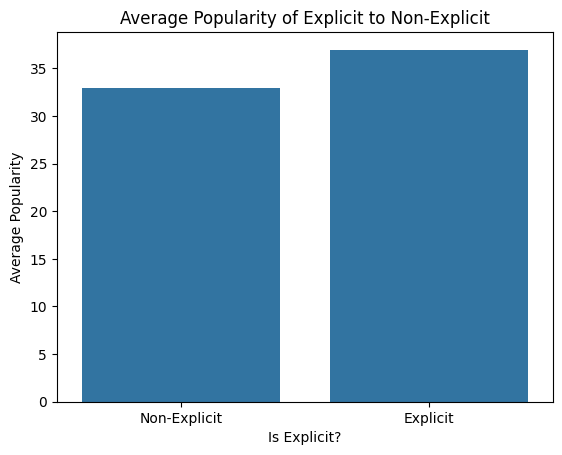

In [7]:
average = df.groupby("explicit")["popularity"].mean()

sns.barplot(data=df, x="explicit", y="popularity", errorbar=None)
plt.title("Average Popularity of Explicit to Non-Explicit")
plt.xlabel("Is Explicit?")
plt.ylabel("Average Popularity")
plt.xticks([0, 1], ["Non-Explicit", "Explicit"])
plt.show()

In this visualisation, it becomes apparent that songs that include explicit lyrics are, on average, more popular than those without. 

Despite the consideration made in favour of explicit lyrics, it must be pointed out that the size of each category may have affected the overall score of explicit songs, as non-explicit songs will have many songs that perform worse by virtue of containing a greater library than explicit songs.

## Additional Visualisation

Another Visualisation of interest was the top 10 genres of music by average popularity, which will be shown below.

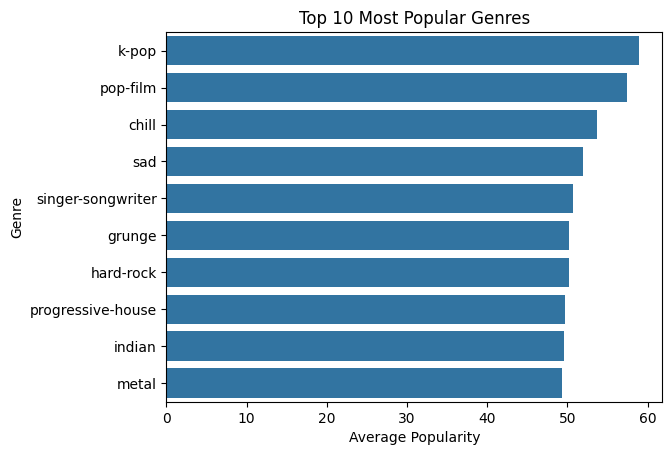

In [12]:
top10 = (df.groupby("track_genre")["popularity"].mean().nlargest(10))
plot = top10.reset_index()

sns.barplot(data=plot, y="track_genre", x="popularity", errorbar=None)

plt.title("Top 10 Most Popular Genres")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()

As visible in the above plot, these are the top 10 most popular genre, based on their average popularity.

As with the prior visualisation, there may be issues in the relative sizing of each genre which may not be visible, they shouldn't be too relevant, though it may be important to keep in mind for more in depth analysis.

---

# Next Steps

Following the EDA, a dashboard may now be created, and analysis may proceed.